fcm


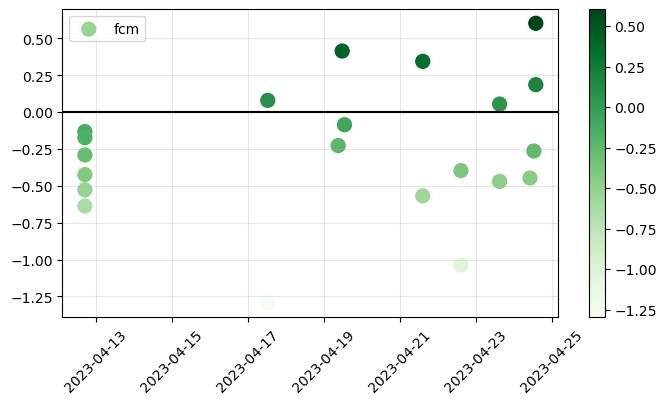

In [57]:
## New Growth/Grazing data
from smode_import import *

## add Chla values to corresponding dilution exp number

df_chla = pd.read_csv('../smode_growth_grazing_chla_qc_10_2025.csv')
df_chla['chla']

df = pd.read_csv('../smode_growth_grazing_fcm_nanoeuks_qc_10_2025.csv')
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df = df.merge(df_chla[['Expt_ID', 'chla']], on='Expt_ID', how='left')

unique_casts = np.unique(df['cast'])
unique_depths = np.unique(df['depth'])

# --- Choose which rate set to load: "fcm" or "exp"
for rate_source in [ "fcm" ]:#, "exp" ]:
    print(rate_source)
    # Map suffix
    grazing_col = f"grazing_rate_nanoeuks_{rate_source}_dil"
    growth_col  = f"growth_rate_nanoeuks_{rate_source}_dil"
    grazing_se_col = f"grazing_se_nanoeuks_{rate_source}_dil"
    growth_se_col  = f"growth_se_nanoeuks_{rate_source}_dil"
    chla_col = f"chla"
    
    casts, depths, grazings, growths, chla, times, lats, lons, expt_ID, grazing_se, growth_se = ([] for _ in range(11))
    
    for cast in unique_casts:
        for depth in unique_depths:
            rows = np.where((np.array(df.cast)==cast) & (np.array(df.depth)==depth))[0]
            if len(rows) >= 1:
                row = rows[0]
                casts.append(np.array(df.cast)[row])
                depths.append(np.array(df.depth)[row])
                grazings.append(np.array(df[grazing_col])[row])            
                growths.append(np.array(df[growth_col])[row])
                times.append(np.array(df.time)[row]) 
                lats.append(np.array(df.lat)[row]) 
                lons.append(np.array(df.lon)[row])
                expt_ID.append(np.array(df.Expt_ID)[row])
                grazing_se.append(np.array(df[grazing_se_col])[row])
                growth_se.append(np.array(df[growth_se_col])[row])
                chla.append(np.array(df[chla_col])[row])
                
    new_dataset = xr.Dataset(
        {
            'cast': ('time', casts),
            'depth': ('time', depths),
            'grazing': ('time', grazings),
            'growth': ('time', growths),
            'chla': ('time', chla),
            'time': ('time', times),
            'lat': ('time', lats),
            'lon': ('time', lons),
            'expt_ID': ('time', expt_ID),
            'grazing_se': ('time', grazing_se),
            'growth_se': ('time', growth_se),
        },
        attrs={'name': f'Growth and Grazing Rates ({rate_source.upper()})'},
    )
    
    new_dataset = new_dataset.sortby('time')
    #new_dataset = new_dataset.where(new_dataset.grazing<0, drop=True)

# plot
plt.figure(figsize=(8,4))
c=plt.scatter(new_dataset.time, new_dataset.grazing,
    marker='o', s=100, c= new_dataset.grazing, cmap='Greens',
    label=rate_source
)
plt.colorbar(c)
plt.axhline(0,c='k')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.legend();

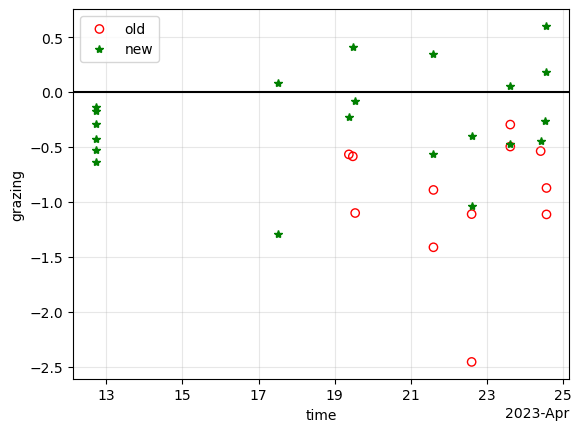

In [58]:
old_dataset = xr.open_dataset('eddy_biology_old.nc')
plt.scatter(old_dataset.time, old_dataset.grazing, marker='o', 
            edgecolor='r', facecolor='none', label='old')
(new_dataset.grazing).plot(marker='*', linestyle='',c='g', label='new')
plt.legend()
plt.grid(alpha=0.3)
plt.axhline(0,c='k');

In [59]:
old_dataset = xr.open_dataset('eddy_biology_old.nc')
dist_values = []

for t in new_dataset.time.values:
    # Find indices in old_dataset with matching time
    matches = np.where(old_dataset.time.values == t)[0]
    if len(matches) > 0:
        # Grab first dist_from_core corresponding to that time
        dist = old_dataset['dist_from_core'].isel(time=matches[0]).values.item()
    else:
        # No matching time, assign NaN or some default
        dist = np.nan
    dist_values.append(dist)

# Now add this dist_from_core array as a new variable in new_dataset
new_dataset = new_dataset.assign_coords(time=new_dataset.time)  # ensure coords okay
new_dataset['dist_from_core'] = ('time', dist_values)

# put all the variables as function of dist_from_core
new_dataset = new_dataset.assign_coords(dist_from_core=new_dataset['dist_from_core'])
new_dataset = new_dataset.swap_dims({'time': 'dist_from_core'})
#new_dataset.to_netcdf('eddy_biology.nc')
new_dataset

<xarray.Dataset> Size: 3kB
Dimensions:         (dist_from_core: 21)
Coordinates:
    time            (dist_from_core) datetime64[ns] 168B 2023-04-12T17:09:54 ...
  * dist_from_core  (dist_from_core) float64 168B nan nan nan ... 41.59 41.59
Data variables:
    cast            (dist_from_core) int64 168B 1 1 1 5 5 5 ... 16 17 19 20 20
    depth           (dist_from_core) int64 168B 5 10 27 5 10 28 ... 10 5 5 5 10
    grazing         (dist_from_core) float64 168B -0.5278 -0.1323 ... 0.1866
    growth          (dist_from_core) float64 168B 0.5545 0.5548 ... -0.03261
    chla            (dist_from_core) float64 168B 1.499 2.082 ... 1.956 2.466
    lat             (dist_from_core) float64 168B 37.02 37.02 ... 36.81 36.81
    lon             (dist_from_core) float64 168B -123.8 -123.8 ... -124.2
    expt_ID         (dist_from_core) <U11 924B 'Dil1C1N21' ... 'Dil45C20N20'
    grazing_se      (dist_from_core) float64 168B 0.09019 0.06217 ... 0.03943
    growth_se       (dist_from_core) float64 168B 0.05952 0.0381 ... 0.03269
Attributes:
    name:     Growth and Grazing Rates (FCM)

In [101]:
new_dataset.sortby('dist_from_core')

<xarray.Dataset> Size: 3kB
Dimensions:         (dist_from_core: 21)
Coordinates:
    time            (dist_from_core) datetime64[ns] 168B 2023-04-19T11:30:00 ...
  * dist_from_core  (dist_from_core) float64 168B 0.8612 2.287 2.287 ... nan nan
Data variables:
    cast            (dist_from_core) int64 168B 11 15 15 12 9 13 ... 5 5 8 8 19
    depth           (dist_from_core) int64 168B 10 5 10 10 5 5 ... 10 28 10 28 5
    grazing         (dist_from_core) float64 168B 0.4149 -1.038 ... -0.2635
    growth          (dist_from_core) float64 168B -0.1608 1.382 ... 0.9933
    chla            (dist_from_core) float64 168B 3.183 2.74 ... nan 0.9436
    lat             (dist_from_core) float64 168B 36.98 36.89 ... 37.12 36.83
    lon             (dist_from_core) float64 168B -123.9 -124.1 ... -124.2
    expt_ID         (dist_from_core) <U11 924B 'Dil18C11N20' ... 'Dil40C19N24'
    grazing_se      (dist_from_core) float64 168B 0.4354 0.7952 ... 0.3899
    growth_se       (dist_from_core) float64 168B 0.2775 0.4961 ... 0.2774
Attributes:
    name:     Growth and Grazing Rates (FCM)

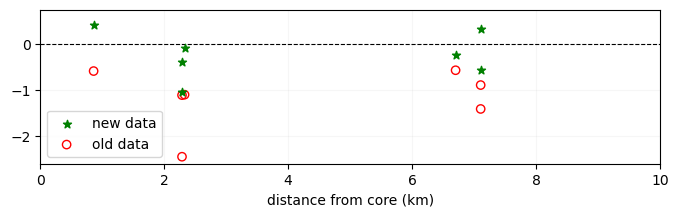

In [96]:
plt.figure(figsize=(8,2))
plt.scatter(new_dataset.dist_from_core, new_dataset.grazing, 
            marker='*', c='g', zorder=101, label='new data')
plt.scatter(old_dataset.dist_from_core, old_dataset.grazing, 
            marker='o', facecolor='none', edgecolor='r', label='old data')
plt.xlabel('distance from core (km)')
plt.grid(alpha=0.1)
plt.xlim(0,10)
plt.axhline(0,c='k',lw=0.8, linestyle='--')
plt.legend()
plt.show();

In [64]:
df_chla

,expt_num,Expt_ID,grazing_rate_exp_dil,growth_rate_exp_dil,grazing_se_exp_dil,growth_se_exp_dil,grazing_rate_fcm_dil,growth_rate_fcm_dil,grazing_se_fcm_dil,growth_se_fcm_dil,chla
0,1,Dil1C1N21,-0.694016,0.545891,0.140634,0.091766,-0.419227,0.394258,0.042003,0.022713,1.498734
1,2,Dil2C1N20,-0.742936,1.573824,0.127753,0.078020,-0.556863,1.227917,0.399940,0.315342,1.498734
2,3,Dil3C1N17,-0.558895,0.798598,0.269271,0.164447,-0.466790,0.719735,0.240710,0.147492,2.082452
3,5,Dil5C5N17,0.143016,0.256840,0.412954,0.252195,-0.234924,0.373819,1.112783,0.696975,1.070806
4,6,Dil6C5N19,0.171817,-0.009989,0.443660,0.270948,0.044968,0.097368,0.478293,0.291778,1.070806
5,7,Dil7C5N16,-0.214448,0.669262,0.086254,0.052676,-0.104700,0.569131,0.119285,0.073723,0.869660
6,9,Dil9C8N23,-1.402941,1.025091,0.217192,0.132641,-1.249740,0.918593,0.380639,0.179756,3.706808
7,10,Dil10C8N24,-0.749060,1.223107,0.091751,0.056033,-0.767269,1.246788,0.250364,0.151805,3.706808
8,11,Dil11C8N20,-1.156050,1.037743,0.234208,0.143033,-1.982288,1.542685,0.951995,0.448652,4.665747
9,13,Dil13C9N23,-0.546065,0.538641,0.586707,0.358308,-0.612472,0.599776,0.590182,0.360222,2.230878


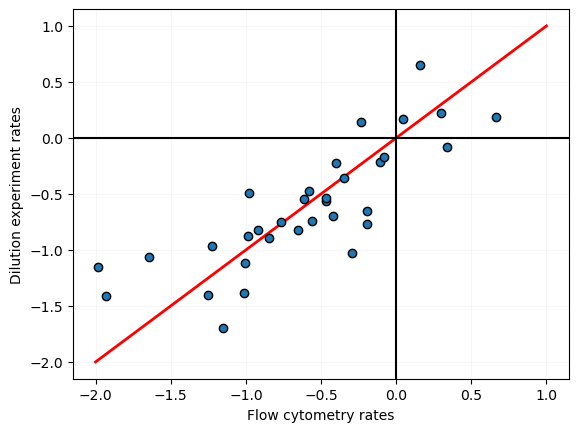

In [91]:
plt.scatter(df_chla['grazing_rate_fcm_dil'], df_chla['grazing_rate_exp_dil'].values, marker='o', edgecolor='k',zorder=101)
plt.plot(np.linspace(-2,1,10),np.linspace(-2,1,10),c='r',linestyle='-',lw=2)
plt.axhline(0,c='k',linestyle='-')
plt.axvline(0,c='k',linestyle='-')
plt.grid(alpha=0.1)
plt.xlabel('Flow cytometry rates')
plt.ylabel('Dilution experiment rates');